# BCH111 — Stimulus-Stability History (mapping)

**Purpose.** Map the stimulus-delivery stability of subject **BCH111** (chronic
evoked recording at 0.5 Hz) across its `(stim site, record site)` configurations,
gated on access resistance (Rₐ), with per-trial artifact metrics (polarity,
amplitude, shape), seizure counts, and distributional comparisons.

**This notebook is mapping only** — it makes *no* experimental recommendations.
Null / ambiguous / collinear results are reported plainly.

### Wiring convention (operator-confirmed)
In a channel `BCH111<AREA>` the **named** `<AREA>` is the **RECORD** site; the
**unnamed** site is the **STIM** target. So `BCH111SLM` ⇒ *(stim = SR, record = SLM)*.

> ⚠️ The codebase's `stim_map` / `impedance_refresh` attribute the injected current
> — and thus the stored `access_r_kohm` — to the *named* electrode (the opposite
> wiring). We use that positional rule only to *detect* the named electrode and
> swaps; the stored 'Rₐ' here is therefore the ΔV/ΔI measured on the **record**
> channel while the other site is stimulated. It is used purely as a stable,
> monotonic gating signal for interface stability.

Everything is read-only. Heavy trace reads use a windowed HDF5 slice (~170× faster
than reading the full ±500 ms trace).

## 0. Setup

In [1]:
import os, sys, datetime as D
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# repo root on path (run from notebooks/ or repo root)
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) \
    if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if ROOT not in sys.path: sys.path.insert(0, ROOT)
os.chdir(ROOT)   # so relative data/ paths resolve to the repo root

from src.dashboard.data_helpers import load_config
from src.db.store import Store
from src.preictal.isi import parse_chunk_datetime, scored_seizures
from src.utils import evoked_output as eo
from src.chronic_stability import (ra_flatrun as fr, config_timeline as ct,
                                   metrics as M, compare as C, render, report)

ANIMAL = 'BCH111'
cfg = load_config()
store = Store(cfg['database']['path'])
EVOKED_DIR = cfg['chronic_evoked']['evoked_output_dir']
OUT = os.path.join('data', 'derivatives', 'chronic_stability', ANIMAL)
os.makedirs(OUT, exist_ok=True)
ISO = lambda e: D.datetime.fromtimestamp(float(e)).strftime('%Y-%m-%d %H:%M')
print('DB   :', cfg['database']['path'])
print('EVOKED:', EVOKED_DIR)

DB   : D:/code/qc_monitor/data/monitor.db
EVOKED: D:/code/Stimulation-Telemetry-Modulation-NeuroEngineering-Toolkit/daqSignalGenerator/evokedOutput


## 1. Stage 0 — data probe

Ground the analysis: which Rₐ series exist, how many evoked files, how many seizures.

In [2]:
ser = store.impedance_series_by_channel()
ra_keys = sorted(k for k in ser if k[0] == ANIMAL)
for k in ra_keys:
    rows = ser[k]
    print(f'{k[1]:>10}: {len(rows):4d} Rₐ pts  {rows[0]["chunk_datetime"]} .. {rows[-1]["chunk_datetime"]}')
files = sorted(f for f in eo.list_evoked_files(EVOKED_DIR) if ANIMAL in os.path.basename(f))
seiz = scored_seizures(store, ANIMAL)
sz_ep = np.array([s.onset_epoch for s in seiz], float)
# shared day-0 for every wall-clock figure = earliest recording (Day 0)
RECORD_T0 = min(eo.parse_recording_dt(os.path.basename(f)).timestamp()
                for f in files if eo.parse_recording_dt(os.path.basename(f)))
print(f'evoked files: {len(files)}   seizures: {len(seiz)}  '
      f'({ISO(sz_ep.min())} .. {ISO(sz_ep.max())})')
print('Day 0 (recording start):', ISO(RECORD_T0))

 BCH111SLM:  921 Rₐ pts  2026_07_20__14_10_44 .. 2026_08_31__15_37_29
  BCH111SR:  164 Rₐ pts  2026_07_13__15_34_42 .. 2026_07_20__12_52_11
evoked files: 1369   seizures: 52  (2026-07-02 17:26 .. 2026-08-17 02:25)
Day 0 (recording start): 2026-07-02 14:45


## 2. Stage 1 — Rₐ flat-run detection (the stable window)

A period is **stable** when Rₐ is flat. We detect the *longest contiguous flat run*
programmatically. **Criterion:** on a centered 24 h rolling window we require both the
rolling **drift** (|slope|·window) and the rolling **dispersion** (robust SD) to sit
within a few multiples of the series' **noise floor** — the irreducible
sample-to-sample wiggle `nf = 1.4826·MAD(Δr)/√2`.

Why the noise floor and not %-of-median: BCH111's Rₐ is sub-kΩ and its flattest stretch
dips to ~0.13 kΩ; normalising a 0.012 kΩ wiggle by that tiny median would make the
*flattest* window look noisier than a higher-magnitude drifting one. Dropouts are absent
rows (NULL Rₐ is dropped upstream), so gaps come from timestamp deltas; a gap > 6 h breaks
a run. A **lone** spike is flagged but tolerated (stats are computed with spikes excluded);
**two adjacent** spikes break the run.

In [3]:
# gating series = the SLM record electrode's Ra trend (Config B)
def ra_series(channel):
    rows = ser.get((ANIMAL, channel), [])
    te = np.array([parse_chunk_datetime(r['chunk_datetime']).timestamp() for r in rows], float)
    r  = np.array([r['access_r_kohm'] for r in rows], float)
    return te, r

GATE_CH = 'BCH111SLM'
te, r = ra_series(GATE_CH)
th = (te - te[0]) / 3600.0
run = fr.detect_longest_flat_run(th, r, te, win_h=24, gap_tol_h=6, disp_k=4.0, slope_k=6.0)
print('STABLE WINDOW:', ISO(run['epoch_start']), '->', ISO(run['epoch_end']))
print(f"  duration {run['duration_h']:.1f} h · {run['n_samples']} Rₐ pts · "
      f"trial-index {run['idx_start']}–{run['idx_end']} · median Rₐ "
      f"{run['median_ra_kohm']:.3f} kΩ · robust CV {run['robust_cv_pct']:.1f}%")
print(f"  noise floor {run['flat_mask']['noise_floor']:.4f} kΩ · "
      f"{len(run['flagged_spikes_in_run'])} lone spike(s) tolerated · "
      f"{run['n_gaps_tolerated']} gap(s), max {run['max_gap_h']:.1f} h")

STABLE WINDOW: 2026-07-22 11:21 -> 2026-07-29 08:56
  duration 165.6 h · 163 Rₐ pts · trial-index 45–207 · median Rₐ 0.138 kΩ · robust CV 17.9%
  noise floor 0.0176 kΩ · 1 lone spike(s) tolerated · 0 gap(s), max 1.3 h


In [4]:
n_sz = int(((sz_ep>=run['epoch_start'])&(sz_ep<=run['epoch_end'])).sum())
print(f'stable window = Day {(run["epoch_start"]-RECORD_T0)/86400:.1f} -> '
      f'{(run["epoch_end"]-RECORD_T0)/86400:.1f} of the record '
      f'({ISO(run["epoch_start"])} -> {ISO(run["epoch_end"])})')
print(f'seizures inside the stable window: {n_sz}  (expectation was >=6 — an OUTCOME, not a criterion)')

stable window = Day 19.9 -> 26.8 of the record (2026-07-22 11:21 -> 2026-07-29 08:56)
seizures inside the stable window: 4  (expectation was >=6 — an OUTCOME, not a criterion)


**Sensitivity sweep** — is the window an artefact of the thresholds? Each bar is the
window detected for one threshold setting; if they line up, the result is robust.

all parameter sets found a run: True


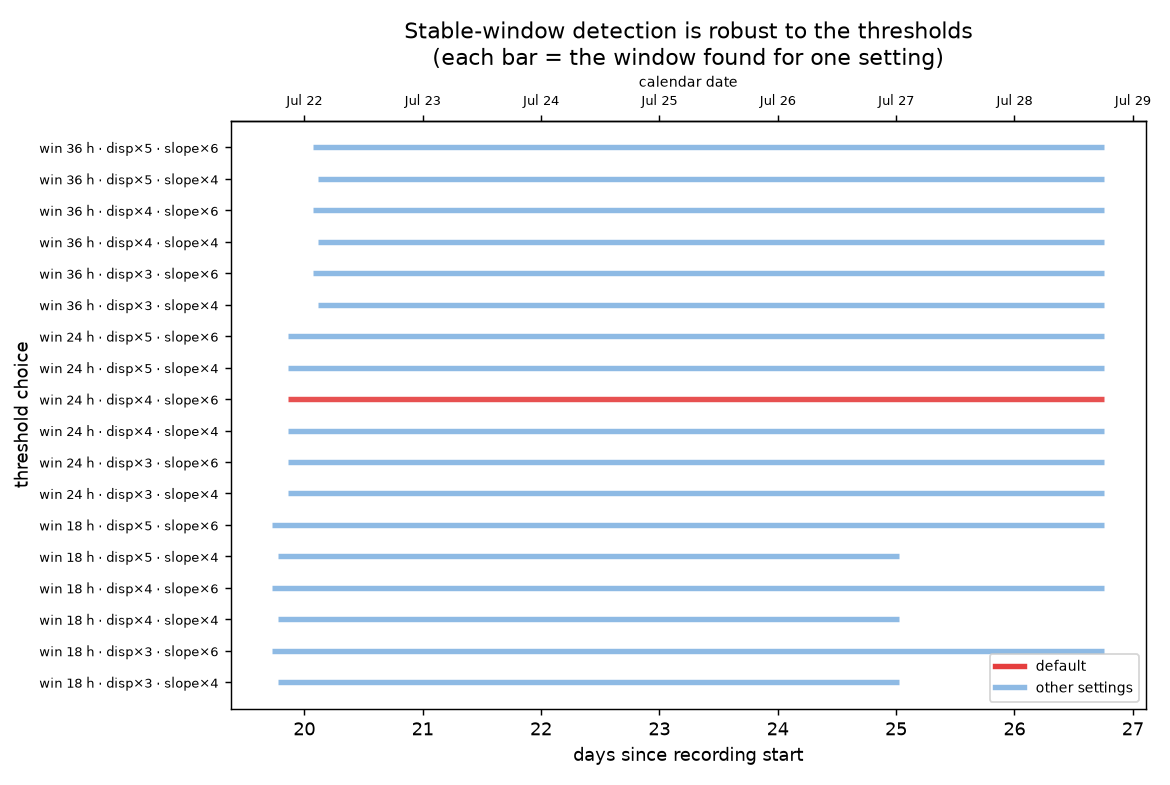

In [5]:
grid = [dict(win_h=w, disp_k=d, slope_k=s) for w in (18,24,36) for d in (3,4,5) for s in (4,6)]
sw = fr.sensitivity_sweep(th, r, te, grid)
print('all parameter sets found a run:', all(g['found'] for g in sw))
default = dict(win_h=24, disp_k=4.0, slope_k=6.0)
png = render.sensitivity_fig(sw, RECORD_T0, default, os.path.join(OUT, f'{ANIMAL}_sensitivity.png'))
display(Image(png))

## 3. Stage 2 — configuration timeline & the swap

A **configuration** = `(stim site, record site)`. We find BCH111's named (record)
electrode per session via the positional stimCopy rule, apply the operator's convention
to label `(stim, record)`, and merge consecutive same-record-site sessions into config
intervals. A change of record site = a **configuration swap**; a change of stim charge at
the same site is a *within-config* event (reported separately).

In [6]:
sessions = ct.bch111_sessions(store, ANIMAL)
intervals = ct.config_intervals(sessions)
events = ct.detect_config_events(sessions)
for iv in intervals:
    end = 'ongoing' if not np.isfinite(iv['end_epoch']) else ISO(iv['end_epoch'])
    print(f"{iv['config_label']:<22} {ISO(iv['start_epoch'])} .. {end:<16} "
          f"modal charge {iv['modal_charge_nC']} nC · {iv['n_sessions']} sessions")
print()
for e in events:
    print(f"{e['event_type']:<14} @ {ISO(e['at_epoch'])}   {e['from_config']} -> {e['to_config']}")
swap = next((e for e in events if e['event_type']=='site_swap'), None)
if swap:
    p = swap['provenance']
    print('\nSWAP provenance:', p['table']+'.'+p['field'],
          '| before:', os.path.basename(p['session_dir_before']),
          '| after:', os.path.basename(p['session_dir_after']))

(stim=SLM, rec=SR)     2026-07-13 15:19 .. 2026-07-20 14:05 modal charge 2.0 nC · 5 sessions
(stim=SR, rec=SLM)     2026-07-20 14:05 .. ongoing          modal charge 5.0 nC · 8 sessions

charge_change  @ 2026-07-13 15:34   (stim=SLM, rec=SR, 5.0nC) -> (stim=SLM, rec=SR, 2.0nC)
charge_change  @ 2026-07-13 15:36   (stim=SLM, rec=SR, 2.0nC) -> (stim=SLM, rec=SR, 1.0nC)
charge_change  @ 2026-07-13 15:38   (stim=SLM, rec=SR, 1.0nC) -> (stim=SLM, rec=SR, 2.0nC)
site_swap      @ 2026-07-20 14:05   (stim=SLM, rec=SR, 2.0nC) -> (stim=SR, rec=SLM, 2.0nC)
charge_change  @ 2026-07-20 14:10   (stim=SR, rec=SLM, 2.0nC) -> (stim=SR, rec=SLM, 5.0nC)
charge_change  @ 2026-08-11 10:51   (stim=SR, rec=SLM, 5.0nC) -> (stim=SR, rec=SLM, 0.0nC)

SWAP provenance: session_config.channel_names | before: chronicStim-5nC-2nC__stimCopy_BCH110SLM_stimCopy_BCH111SR_BCH061SLM_BCH114SLM_ | after: chronicStim-5nC-2nC__stimCopy_BCH110SLM_stimCopy_BCH111SLM_BCH061SLM_BCH114SLM_


### 3a. Access resistance over time, **both** record electrodes

Rₐ for the SR record electrode (Config A) and the SLM record electrode (Config B),
on one wall-clock axis (elapsed days, calendar dates on top), with **battery and cage
change times overlaid as vertical lines**. Battery-change ground truth is the recorder's
software Notes tab (when the recording was stopped/started around a change); the
human-reported per-rig times are approximate. The second figure aligns each configuration
to its own day 0 so the two Rₐ trends are directly comparable.

Read the mechanism off this plot: if Rₐ steps at the battery lines and is otherwise flat,
the supply is implicated; if it steps once and then wanders continuously, the interface is.

battery-change lines: 20 | cage-change lines: 9 | software Notes events: 50


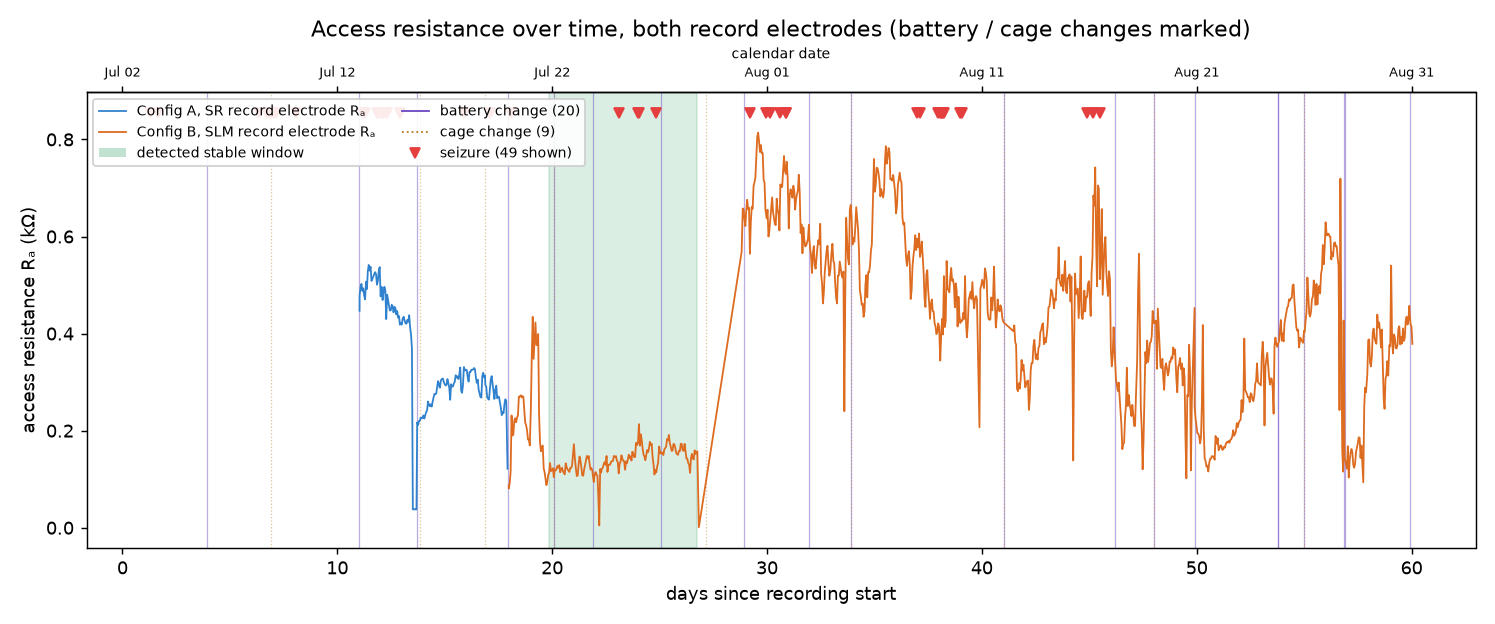

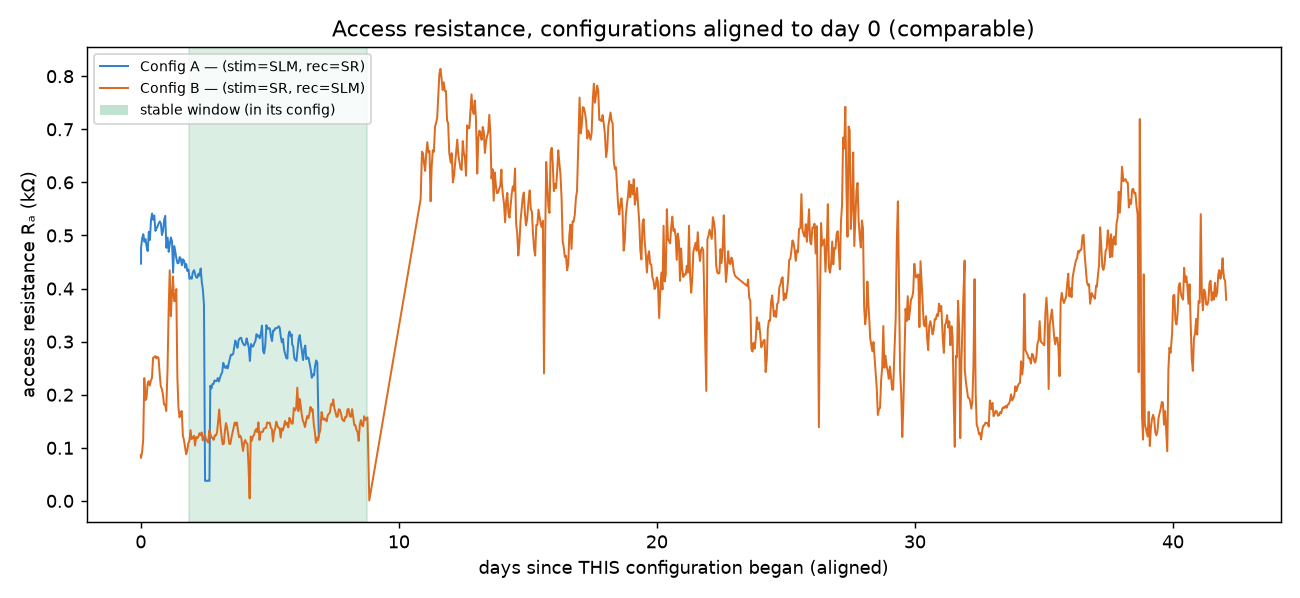

In [7]:
from src.chronic_stability import maintenance as mnt
ra = {k: ra_series(iv['record_channel']) for k, iv in enumerate(intervals)}
mev = mnt.load_events(cfg, float(RECORD_T0), float(max(te.max() for te,_ in ra.values())))
lines = mnt.figure_lines(mev)
print('battery-change lines:', len(lines['battery']), '| cage-change lines:', len(lines['cage']),
      '| software Notes events:', len(mev['software']))
display(Image(render.ra_over_time_fig(ra, intervals, run, sz_ep, os.path.join(OUT, f'{ANIMAL}_ra_over_time.png'), t0=RECORD_T0, events=lines)))
display(Image(render.ra_aligned_fig(ra, intervals, run, os.path.join(OUT, f'{ANIMAL}_ra_aligned.png'))))

## 4. Stages 3–5 — per-trial metrics, distributions, report

The remaining stages read every trial's artifact window (**[-1, 2] ms** on the LFP record
channel), build a **fixed template** = median artifact over the stable window, express the
whole record as deviation from it (correlation + span-normalised RMSE), compute polarity
and peak-to-trough amplitude, count seizures per config, and run the distributional
comparisons with **dependence-aware block-bootstrap** CIs.

`report.run(...)` executes all of this with progress and writes every CSV/PNG plus a
markdown report to `data/derivatives/chronic_stability/BCH111/`. **This reads ~1.4k files
once (a few minutes).**

In [8]:
ctx = report.run(store, ANIMAL, EVOKED_DIR, OUT,
                 flat_params=dict(win_h=24, gap_tol_h=6, disp_k=4.0, slope_k=6.0),
                 n_boot=2000)
print('trials:', ctx['metrics']['epoch'].size, '| configs:', len(ctx['intervals']))

[chronic_stability] enumerating configurations for BCH111 ...


[chronic_stability] 2 configuration(s); detecting stable Rₐ run ...


[chronic_stability] 1369 evoked files; building template over stable window ...


  trials: 1/168 files  1661/min  ETA 0.1 min


  trials: 50/168 files  7652/min  ETA 0.0 min


...

  trials: 1350/1369 files  7329/min  ETA 0.0 min


  trials: 1369/1369 files  7374/min  ETA 0.0 min


[chronic_stability] maintenance: 50 software stop/start events, 17 battery + 8 cage human-reported


[chronic_stability] done -> data\derivatives\chronic_stability\BCH111


trials: 2407939 | configs: 2


### 4a. Per-configuration timeline table

In [9]:
pc = pd.DataFrame(ctx['per_config'])
pc['start'] = pc['start_epoch'].map(ISO)
pc[['config_label','stim_site','record_site','start','duration_h','n_trials',
    'n_seizures','modal_charge_nC','ra_median','amp_median','corr_median',
    'nrmse_median','polarity_switch']]

,config_label,stim_site,record_site,start,duration_h,n_trials,n_seizures,modal_charge_nC,ra_median,amp_median,corr_median,nrmse_median,polarity_switch
0,"(stim=SLM, rec=SR)",SLM,SR,2026-07-13 15:19,166.767778,290107,12,2.0,0.308232,6.744506,-0.994286,0.204888,9272
1,"(stim=SR, rec=SLM)",SR,SLM,2026-07-20 14:05,1010.529444,1657417,27,5.0,0.387044,8.067651,0.425642,0.129977,9958


### 4b. Per-trial metrics + Rₐ over time

X-axis is **elapsed days** (Day 0 = first trial), with calendar dates on the top
axis. Shaded bands = configurations; the green band = the stable window; the red
ticks/lines = seizures. The legend labels every band and series.

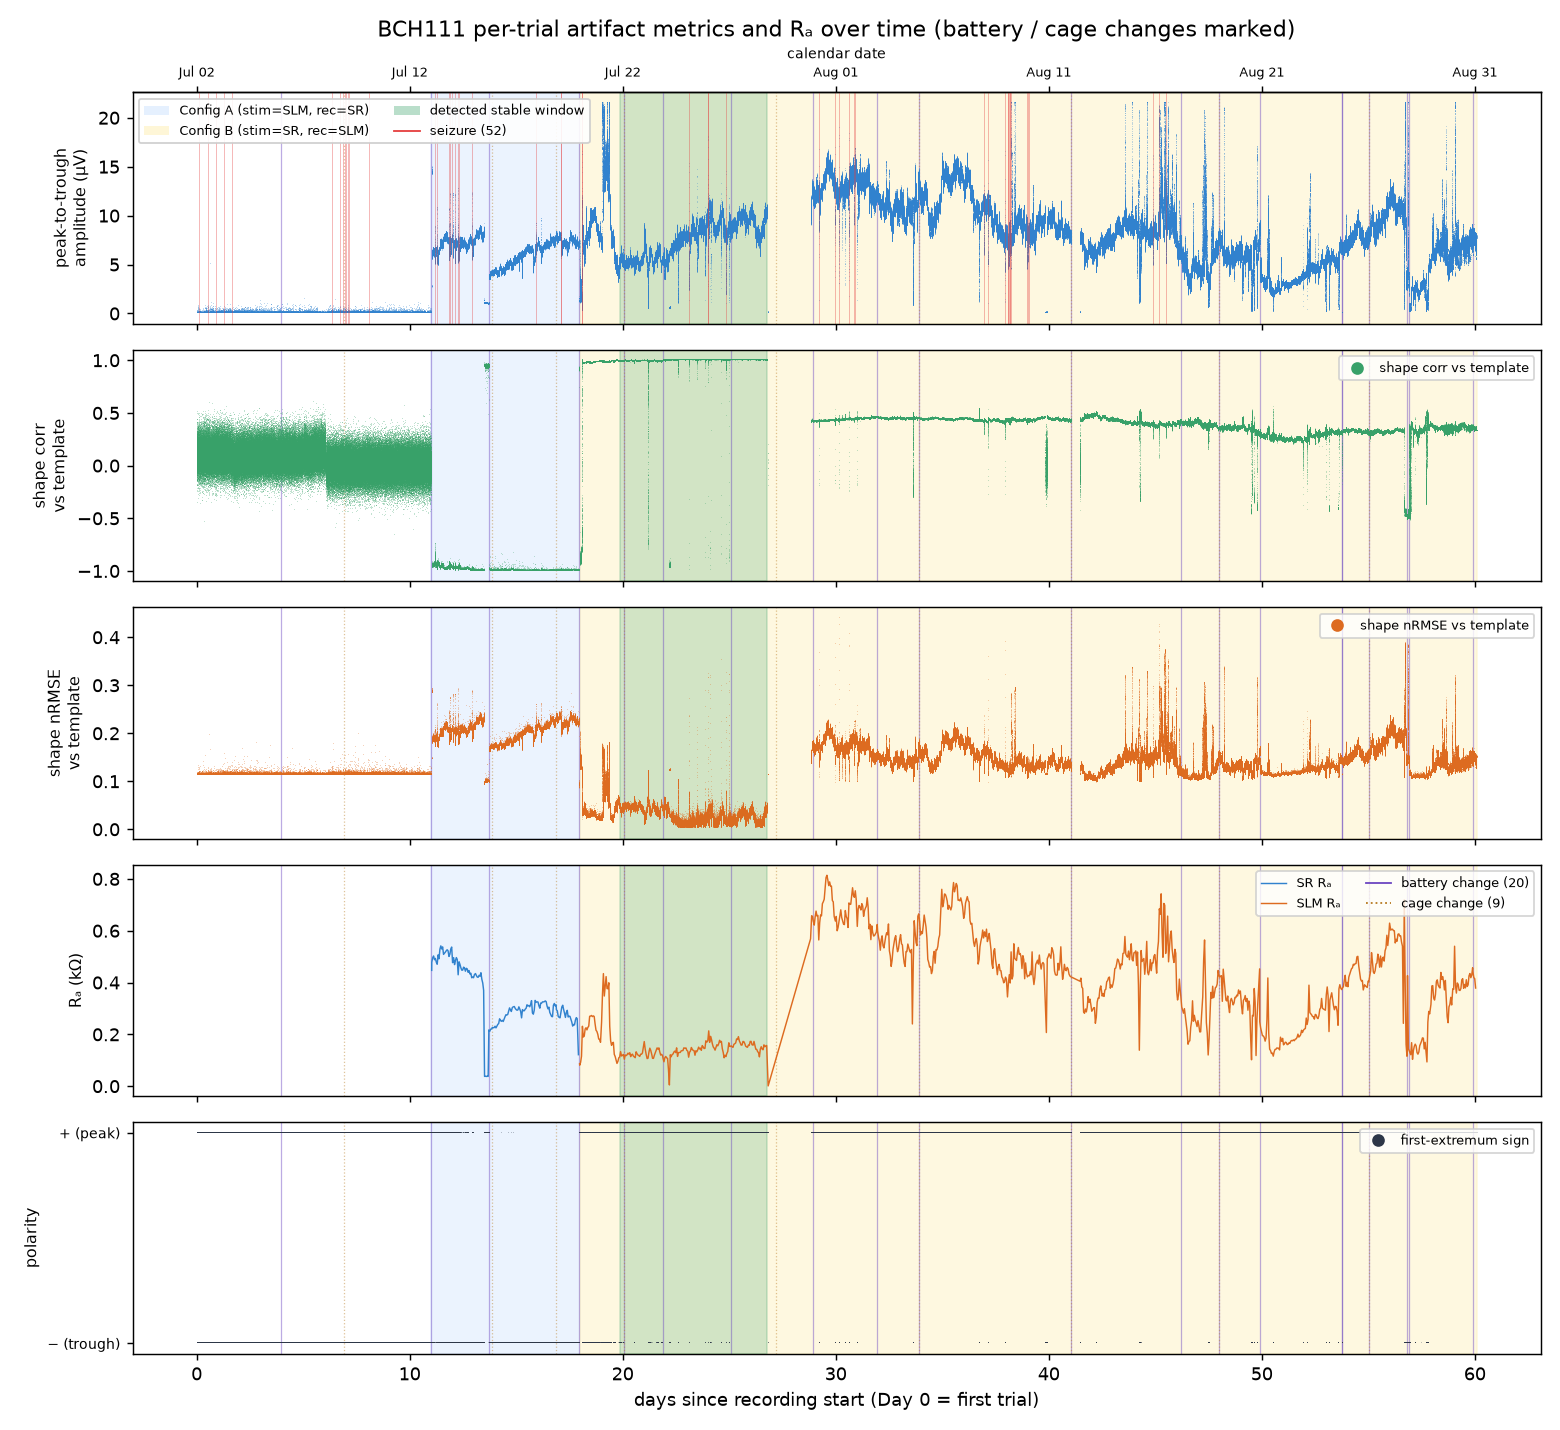

In [10]:
display(Image(os.path.join(OUT, f'{ANIMAL}_metric_timeseries.png')))

### 4c. Raw artifact waveforms — examples, not just summaries

Configs are lettered **A** / **B** exactly as in the timeline table above
(A = the SR-record era, B = the SLM-record era holding the stable window).

- **ERP-image**: a time-ordered SAMPLE of ~8000 artifacts (of ~2.4M total), one real
  trial per row (oldest at the bottom, colour = µV). Not every trial: at this image
  height 8000 rows already exceed the pixels, so more rows would not add detail. It
  still shows the polarity flip at the swap, the flat stable plateau, and later drift.
- **Trace gallery**: ~14 individual example traces per config, plus each config's mean
  and the stable template (dashed).
- **Mean ± SD** artifact per config, overlaid.

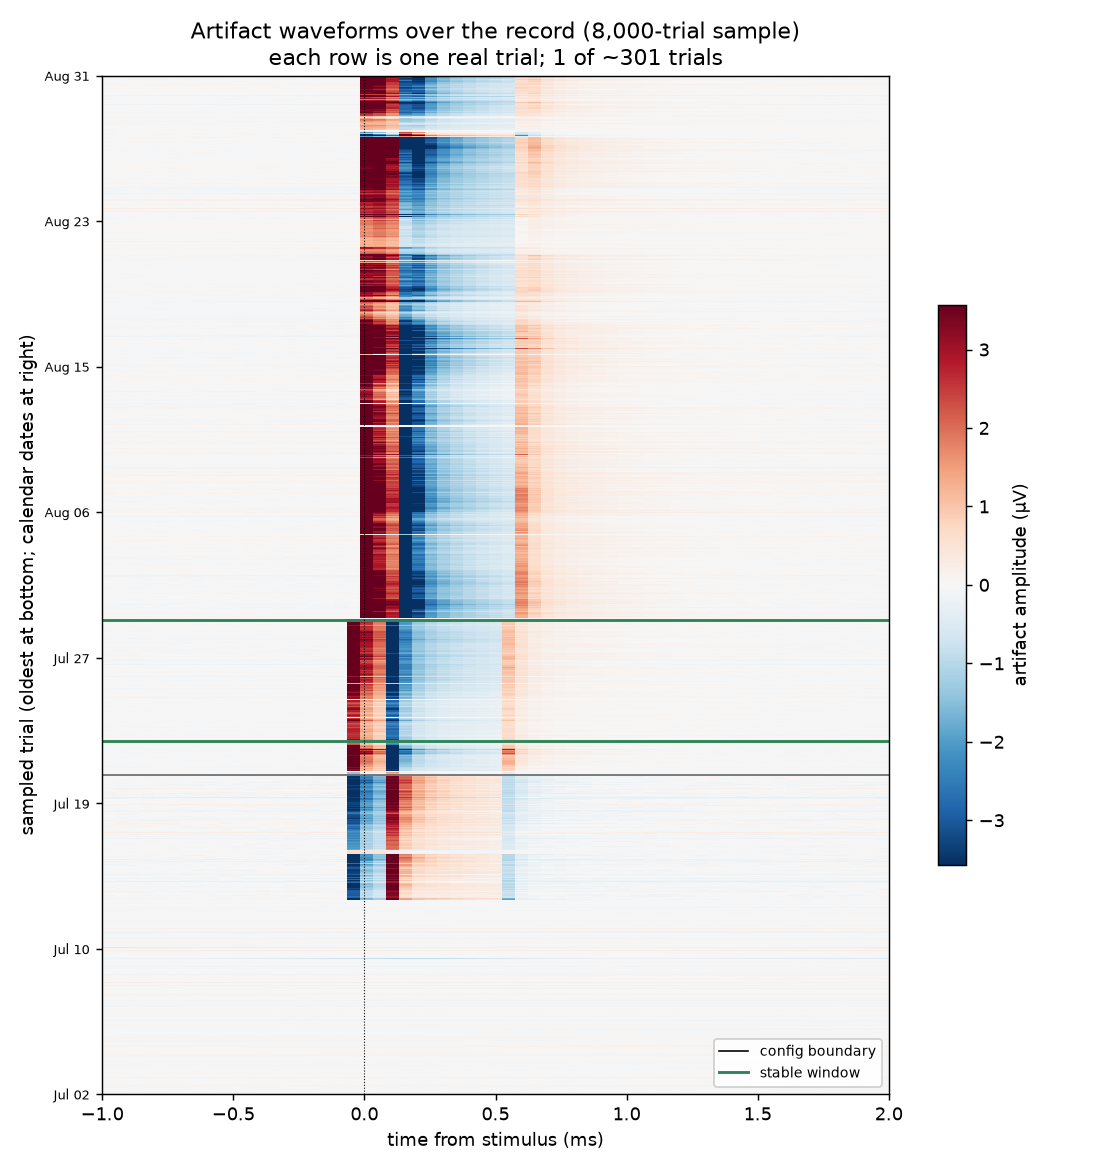

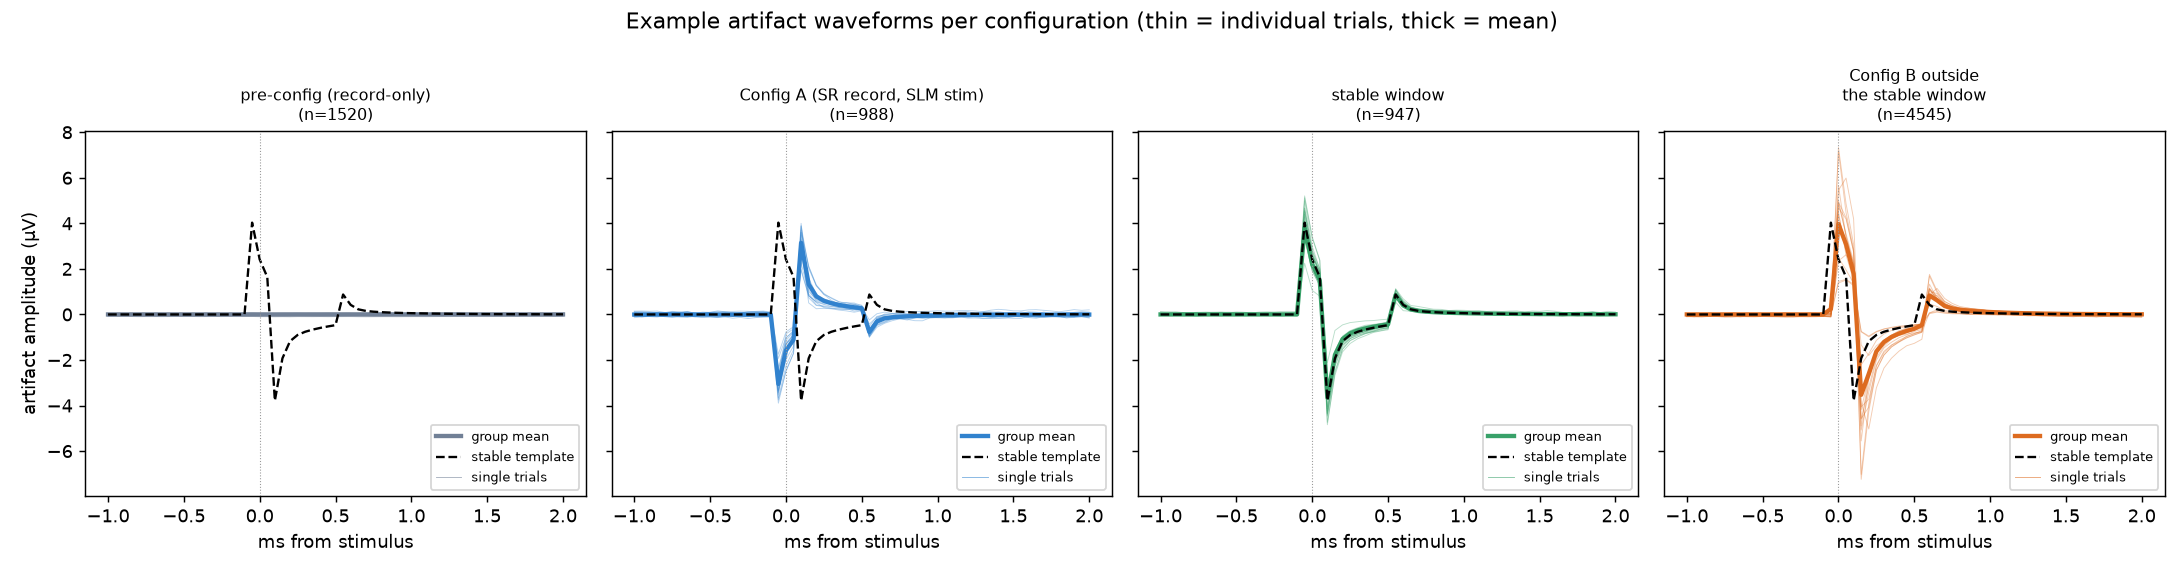

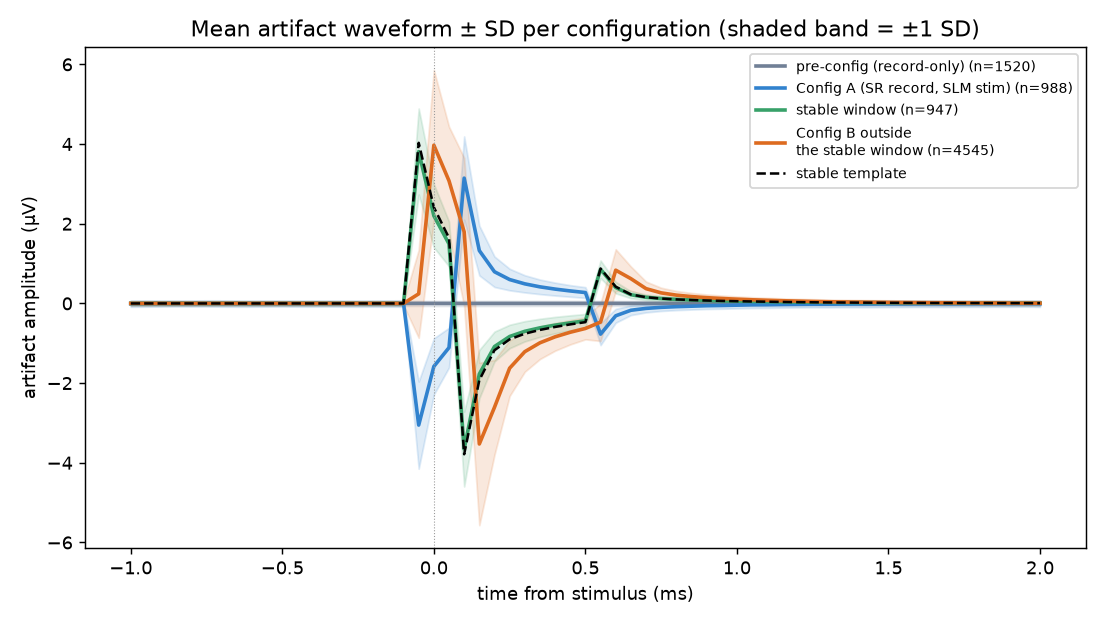

In [11]:
for name in ('erpimage','trace_gallery','mean_traces'):
    display(Image(os.path.join(OUT, f'{ANIMAL}_{name}.png')))

You can pull *any* individual trials yourself — e.g. a handful from the stable window
vs late in Config B — and overlay them:

In [12]:
samp = M.gather_sample_trials(files, ANIMAL, -1.0, 2.0, max_trials=8000)
sci = ct.assign_epochs_to_configs(samp['epoch'], intervals)
s_in = (samp['epoch']>=run['epoch_start']) & (samp['epoch']<=run['epoch_end'])
w = samp['win_ms']; rng = np.random.default_rng(1)
fig, ax = plt.subplots(figsize=(8,4))
for lab, mask, col in [('stable window', s_in, '#38a169'),
                       ('late Config B', (sci==ctx['stable_cfg']) & ~s_in, '#dd6b20')]:
    idx = np.where(mask)[0]
    for j in rng.choice(idx, size=min(20, idx.size), replace=False):
        ax.plot(w, samp['seg'][j], col, lw=0.6, alpha=0.4)
    ax.plot(w, samp['seg'][idx].mean(0), col, lw=2.5, label=lab+' mean')
ax.axvline(0, color='0.6', ls=':'); ax.set_xlabel('ms from stim'); ax.set_ylabel('µV')
ax.legend(); ax.set_title('Individual artifact traces: stable vs late'); plt.show()

  trials: 1/1369 files  11233/min  ETA 0.1 min


  trials: 50/1369 files  7478/min  ETA 0.2 min


  trials: 100/1369 files  7964/min  ETA 0.2 min


  trials: 150/1369 files  6916/min  ETA 0.2 min


  trials: 200/1369 files  7219/min  ETA 0.2 min


...

  trials: 1250/1369 files  6980/min  ETA 0.0 min


  trials: 1300/1369 files  7107/min  ETA 0.0 min


  trials: 1350/1369 files  7228/min  ETA 0.0 min


  trials: 1369/1369 files  7267/min  ETA 0.0 min


C:\Users\hoang392\AppData\Local\Temp\ipykernel_1032\342322202.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.legend(); ax.set_title('Individual artifact traces: stable vs late'); plt.show()


### 4d. Distributions — stable window vs its own config vs the other config

Distributions (ECDF + violin), not point estimates. Note the **cross-config shape caveat**:
the two configs record from *different* electrodes, so correlation/RMSE across configs
conflate stimulus-delivery change with electrode identity — amplitude / polarity / Rₐ are the
cleaner cross-config comparators.

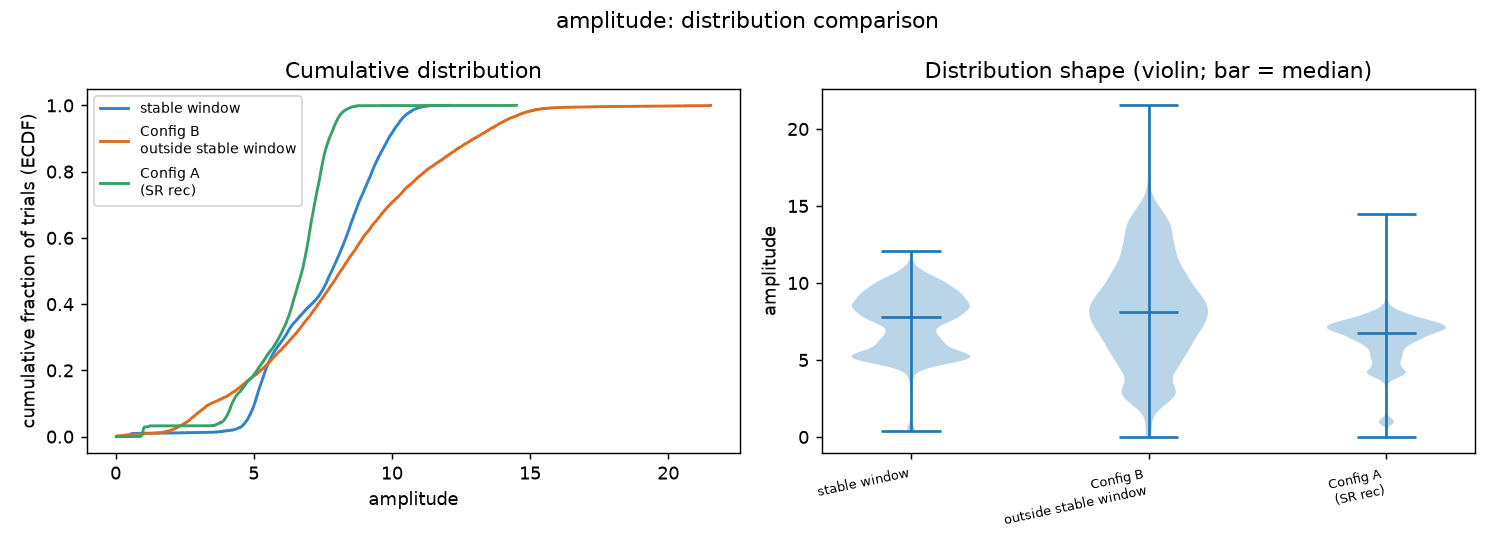

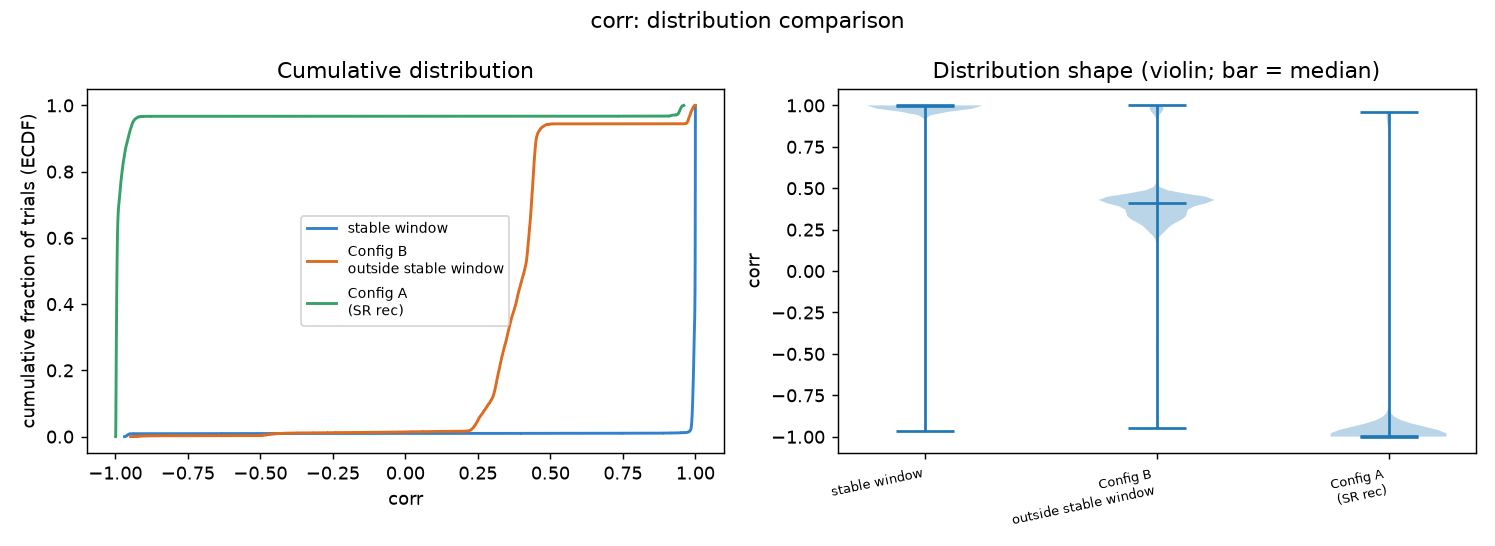

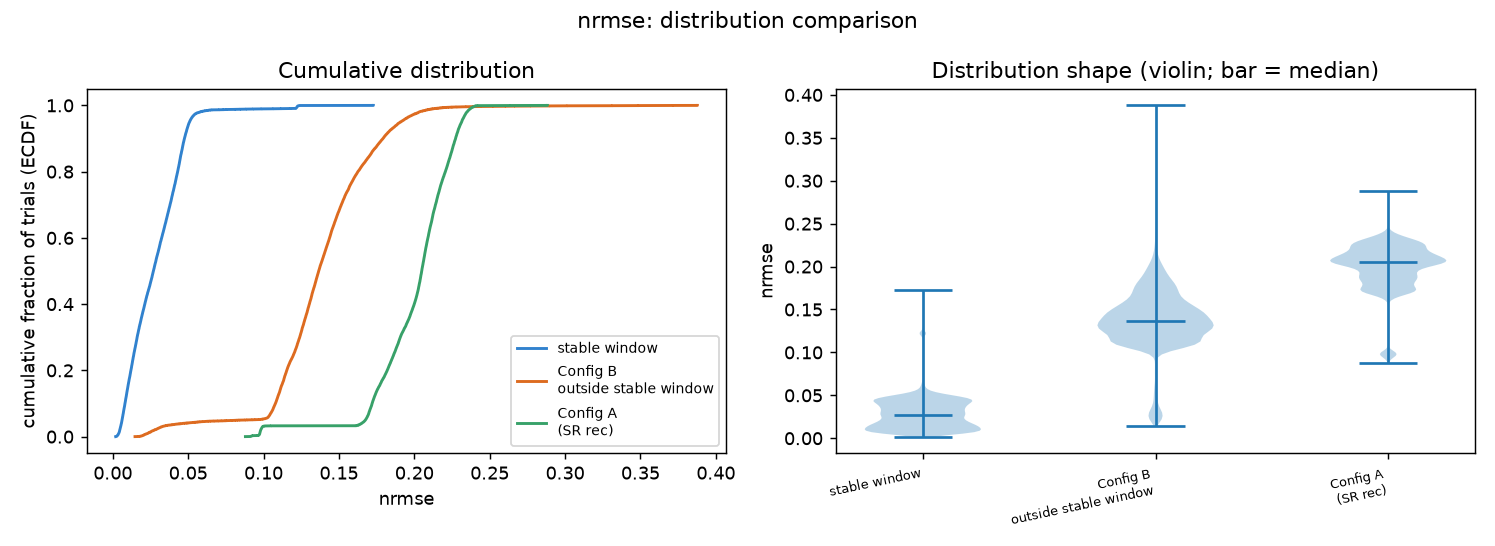

,name,n_a,n_b,median_a,median_b,ks_p,mwu_p,cliffs_delta,median_diff,ci_lo,ci_hi
0,amplitude: stable window vs Config B (SLM reco...,288440,1368977,7.8227,8.1432,0.0,0.0,-0.1249,-0.3205,-0.6763,0.0072
1,"amplitude: Config B (SLM record, SR stim) vs C...",1657417,290107,8.0677,6.7445,0.0,0.0,0.3784,1.3231,1.1125,1.5416
2,amplitude: stable window vs Config A (SR recor...,288440,290107,7.8227,6.7445,0.0,0.0,0.3711,1.0782,0.7406,1.3803
3,"corr: stable window vs Config B (SLM record, S...",288440,1368977,0.9989,0.4100,0.0,0.0,0.9750,0.5889,0.5825,0.5964
4,"corr: Config B (SLM record, SR stim) vs Config...",1657417,290107,0.4256,-0.9943,0.0,0.0,0.9488,1.4199,1.4170,1.4228
5,"corr: stable window vs Config A (SR record, SL...",288440,290107,0.9989,-0.9943,0.0,0.0,0.9980,1.9932,1.9925,1.9938
6,"nrmse: stable window vs Config B (SLM record, ...",288440,1368977,0.0269,0.1366,0.0,0.0,-0.9572,-0.1097,-0.1129,-0.1067
7,"nrmse: Config B (SLM record, SR stim) vs Confi...",1657417,290107,0.1300,0.2049,0.0,0.0,-0.8839,-0.0749,-0.0775,-0.0723
8,"nrmse: stable window vs Config A (SR record, S...",288440,290107,0.0269,0.2049,0.0,0.0,-0.9990,-0.1780,-0.1815,-0.1748


In [13]:
for key in ('amplitude','corr','nrmse'):
    display(Image(os.path.join(OUT, f'{ANIMAL}_dist_{key}.png')))
cmp = pd.DataFrame([c for c in ctx['comparisons'] if 'median_a' in c])
cmp[['name','n_a','n_b','median_a','median_b','ks_p','mwu_p','cliffs_delta',
     'median_diff','ci_lo','ci_hi']].round(4)

### 4d. Collinearity — configuration age vs stability

Configuration age and stability are typically confounded (an older config has drifted
further). We **report** this, not adjust it: the stable window's age band vs the config's
full age range, Spearman ρ(age, metric) per config, and age-stratified ECDFs.

stable window occupies config age 45-211 h of the config's 0-1011 h span (16% of its age)
(stim=SLM, rec=SR) {'amplitude': 0.068, 'corr': -0.716, 'nrmse': 0.401}
(stim=SR, rec=SLM) {'amplitude': -0.372, 'corr': -0.864, 'nrmse': 0.342}


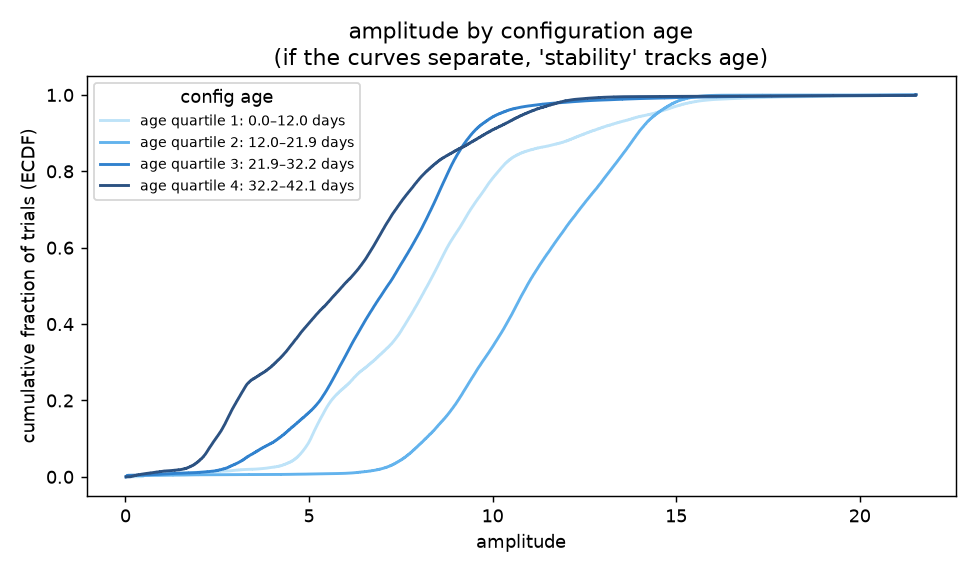

In [14]:
b = ctx['collinearity']['stable_age_band']
print(f"stable window occupies config age {b['stable_age_lo_h']:.0f}-{b['stable_age_hi_h']:.0f} h "
      f"of the config's {b['config_age_lo_h']:.0f}-{b['config_age_hi_h']:.0f} h span "
      f"({100*b['stable_frac_of_config_age']:.0f}% of its age)")
for lab, d in ctx['collinearity']['per_config'].items():
    print(lab, {k: round(d[k]['rho'],3) for k in ('amplitude','corr','nrmse') if k in d})
display(Image(os.path.join(OUT, f'{ANIMAL}_age_amplitude.png')))

## 5. Written report

The full mapping narrative (config timeline, swap provenance, stable window + validation,
distributions, collinearity, caveats) is written to `BCH111_stability_report.md` alongside
the CSV/PNG artifacts. Rendered here for convenience.

In [15]:
from IPython.display import Markdown
with open(os.path.join(OUT, f'{ANIMAL}_stability_report.md'), encoding='utf-8') as f:
    display(Markdown(f.read()))

# BCH111 — Stimulus-Stability History (mapping)

_Generated 2026-08-31 17:47 · read-only · mapping only, no experimental recommendations._

Convention: the NAMED electrode in `BCH111<AREA>` is the RECORD site; the unnamed site is the STIM target. ⚠️ The codebase's stim_map / impedance_refresh attribute the current (and thus the stored `access_r_kohm`) to that named electrode, i.e. the opposite wiring; the stored 'Rₐ' here is therefore the ΔV/ΔI on the RECORD channel while the other site is stimulated. It is used only as a stable, monotonic gating signal for interface stability.

## 1. Configuration timeline

| config | stim | rec | start | end | dur (h) | trials | seizures | charge (nC) | Rₐ med (kΩ) | amp med | corr med | nRMSE med | pol switches |
|---|---|---|---|---|--:|--:|--:|--:|--:|--:|--:|--:|--:|
| **A** (stim=SLM, rec=SR) | SLM | SR | 2026-07-13 15:19 | 2026-07-20 14:05 | 167 | 290107 | 12 | 2.0 | 0.308 | 6.74 | -0.994 | 0.205 | 9272 |
| **B** (stim=SR, rec=SLM) | SR | SLM | 2026-07-20 14:05 | ongoing | 1011 | 1657417 | 27 | 5.0 | 0.387 | 8.07 | 0.426 | 0.130 | 9958 |

Total seizures for BCH111 (record-wide): 52.

## 2. Configuration swap(s) & within-config events

- **SITE SWAP @ 2026-07-20 14:05**: (stim=SLM, rec=SR, 2.0nC) → (stim=SR, rec=SLM, 2.0nC). Provenance: `session_config.channel_names`, session before `chronicStim-5nC-2nC__stimCopy_BCH110SLM_stimCopy_BCH111SR_BCH061SLM_BCH114SLM_` → after `chronicStim-5nC-2nC__stimCopy_BCH110SLM_stimCopy_BCH111SLM_BCH061SLM_BCH114SLM_` (report ch 2, fp mapped).

Within-config charge changes (NOT configuration swaps): 2026-07-13 15:34 (stim=SLM, rec=SR, 5.0nC)→(stim=SLM, rec=SR, 2.0nC); 2026-07-13 15:36 (stim=SLM, rec=SR, 2.0nC)→(stim=SLM, rec=SR, 1.0nC); 2026-07-13 15:38 (stim=SLM, rec=SR, 1.0nC)→(stim=SLM, rec=SR, 2.0nC); 2026-07-20 14:10 (stim=SR, rec=SLM, 2.0nC)→(stim=SR, rec=SLM, 5.0nC); 2026-08-11 10:51 (stim=SR, rec=SLM, 5.0nC)→(stim=SR, rec=SLM, 0.0nC)

## 3. Stable window (longest programmatic flat Rₐ run)

Detected on the **SLM** record-electrode Rₐ trend (Config B, (stim=SR, rec=SLM)). See `BCH111_ra_over_time.png` (both electrodes on one axis) and `BCH111_ra_aligned.png` (configs aligned, comparable).

- **Boundaries:** 2026-07-22 11:21 → 2026-07-29 08:56 = **day 19.9 → 26.8** of the record (trial-index 45–207 on the Rₐ series).
- **Duration:** 165.6 h (6.9 days) · 163 Rₐ points · median Rₐ 0.138 kΩ · robust CV 17.9%.
- **Artifacts:** 1 lone spike(s) tolerated; 0 gap(s) tolerated, max gap 1.3 h (a gap > tolerance would break the run).
- **Seizures inside the window:** **4** (expectation was ≥6; this is an OUTCOME, not a selection criterion).
- **Position vs swap:** the window starts 1.9 days after the configuration it lives in began.

## 4. Raw artifact waveforms (examples, not summaries)

Configs are lettered A/B as in §1. From a uniform time-ordered sample of 8,000 trials (of ~2,407,939 total across the record):
- `BCH111_erpimage.png` = that sample stacked by time, ONE real trial per row (colour = µV): the whole history at the waveform level (polarity flips, amplitude drift, the swap, the flat stable plateau). Note it is a sample, not every trial; at this image height even the sample already exceeds the pixel rows.
- `BCH111_trace_gallery.png` — ~14 individual example traces per config + the config mean + the stable template (dashed).
- `BCH111_mean_traces.png` — mean artifact ± SD per config, overlaid.

## 5. Distributions (not point estimates)

| comparison | n(a) | n(b) | med(a) | med(b) | KS p | MWU p | Cliff's δ | Δmedian [95% block-CI] |
|---|--:|--:|--:|--:|--:|--:|--:|---|
| amplitude: stable window vs Config B (SLM record, SR stim) outside the stable window | 288440 | 1368977 | 7.823 | 8.143 | 0.0e+00 | 0.0e+00 | -0.125 | -0.321 [-0.676, +0.007] |
| amplitude: Config B (SLM record, SR stim) vs Config A (SR record, SLM stim) | 1657417 | 290107 | 8.068 | 6.745 | 0.0e+00 | 0.0e+00 | +0.378 | +1.323 [+1.112, +1.542] |
| amplitude: stable window vs Config A (SR record, SLM stim) | 288440 | 290107 | 7.823 | 6.745 | 0.0e+00 | 0.0e+00 | +0.371 | +1.078 [+0.741, +1.380] |
| corr: stable window vs Config B (SLM record, SR stim) outside the stable window | 288440 | 1368977 | 0.999 | 0.410 | 0.0e+00 | 0.0e+00 | +0.975 | +0.589 [+0.582, +0.596] |
| corr: Config B (SLM record, SR stim) vs Config A (SR record, SLM stim) | 1657417 | 290107 | 0.426 | -0.994 | 0.0e+00 | 0.0e+00 | +0.949 | +1.420 [+1.417, +1.423] |
| corr: stable window vs Config A (SR record, SLM stim) | 288440 | 290107 | 0.999 | -0.994 | 0.0e+00 | 0.0e+00 | +0.998 | +1.993 [+1.993, +1.994] |
| nrmse: stable window vs Config B (SLM record, SR stim) outside the stable window | 288440 | 1368977 | 0.027 | 0.137 | 0.0e+00 | 0.0e+00 | -0.957 | -0.110 [-0.113, -0.107] |
| nrmse: Config B (SLM record, SR stim) vs Config A (SR record, SLM stim) | 1657417 | 290107 | 0.130 | 0.205 | 0.0e+00 | 0.0e+00 | -0.884 | -0.075 [-0.078, -0.072] |
| nrmse: stable window vs Config A (SR record, SLM stim) | 288440 | 290107 | 0.027 | 0.205 | 0.0e+00 | 0.0e+00 | -0.999 | -0.178 [-0.182, -0.175] |

Polarity (polarity: Config B (SLM record, SR stim) vs Config A (SR record, SLM stim)): frac(+) 0.971 vs 0.159, Fisher p 0.0e+00.

_CIs use a dependence-aware moving-block bootstrap (consecutive trials are autocorrelated; an iid bootstrap would understate the CI)._

## 6. Configuration age vs stability (collinearity — reported, not adjusted)

The stable window occupies configuration age 45–211 h, out of the config's full 0–1011 h span (16% of its age range). Stability and age are therefore confounded — a stable-vs-full difference is read JOINTLY with age.

Spearman ρ(config age, metric) per configuration:

- (stim=SLM, rec=SR): amplitude ρ=+0.07 (p=1.6e-295), corr ρ=-0.72 (p=0.0e+00), nrmse ρ=+0.40 (p=0.0e+00)
- (stim=SR, rec=SLM): amplitude ρ=-0.37 (p=0.0e+00), corr ρ=-0.86 (p=0.0e+00), nrmse ρ=+0.34 (p=0.0e+00)

## 7. Caveats & null/ambiguous results

- **Cross-config shape:** the two configurations record from DIFFERENT electrodes, so corr/nRMSE of the other config vs a stable-config template conflate stimulus-delivery change with record-electrode identity. Amplitude / polarity / Rₐ are the cleaner cross-config comparators.
- **Age–stability collinearity** is intrinsic (see §5) and is not adjusted away.
- **Seizure expectation:** the stable window holds 4 seizures, below the anticipated ≥6 — reported as an outcome.
- **Timestamps** are naive local wall-clock (evoked filenames and DB chunk_datetime share the same basis; no UTC layer).

## 8. Maintenance log (recording stop/start around changes)

Ground truth = the recorder's software Notes tab (50 battery/cage stop/start events in the record window). The per-rig Maintenance Tracker (Rig C) adds 17 battery and 8 cage change times that are HUMAN-reported and approximate (not the true instant of the change).

- 3 battery change(s) fall INSIDE the stable window (Rₐ robust CV 17.9%); Rₐ stays flat across them.
- The configuration swap (2026-07-20 14:05) is 0.2 h from the nearest logged battery change (the swap and a battery change were logged together).

**Software stop/start events (ground truth):**

| datetime | event | kind | note |
|---|---|---|---|
| 2026-07-06 13:38 | stop | battery | Battery change |
| 2026-07-06 13:43 | start | battery | BAttery change. |
| 2026-07-07 10:29 | manual | cage | Cage open (test) |
| 2026-07-09 12:56 | stop | cage | Cage cleaning |
| 2026-07-09 13:15 | start | cage | Cage cleaning |
| 2026-07-13 14:38 | stop | battery | Battery change, adding BCH114, setting up to stimulate BCH111. |
| 2026-07-13 15:19 | start | battery | amplifiers connections changed, daq stim 2 added, batteries taken from upstairs  |
| 2026-07-16 07:53 | stop | battery | Stim amplitude dropped, likely due to lapse in battery replacements. Doh. |
| 2026-07-16 07:57 | start | battery | BAttery changed. One battery had 2 volts, the other had 11-12 volts left |
| 2026-07-16 11:35 | stop | cage | Cage cleaning |
| 2026-07-16 11:53 | start | cage | Cage cleaning |
| 2026-07-19 12:01 | stop | cage | Nametag for BCH110 had fell off, paused recording to stick the tag back on the c |
| 2026-07-19 12:03 | start | cage | Paused recording to put BCH110's tag back on the cage |
| 2026-07-20 13:56 | stop | battery | Battery changed, and noticed notified for stim artifact change. |
| 2026-07-20 14:05 | start | battery | Swapped electrode configurations. Replaced batteries |
| 2026-07-20 14:18 | start | cage | I was looking at teh wrong channel on my program (ch 0 + 1). Now im looking at t |
| 2026-07-22 16:15 | stop | both | Battery Change and Cage Cleaning |
| 2026-07-22 16:35 | start | both | Battery Change and Cage Cleaning |
| 2026-07-24 12:10 | stop | battery | battery change |
| 2026-07-24 12:11 | start | battery | Battery change |
| 2026-07-27 16:51 | stop | battery | Battery change |
| 2026-07-27 16:56 | start | battery | battery change |
| 2026-07-29 10:37 | start | battery | Battery Change, removed BCH110, added BCH112. |
| 2026-07-29 19:05 | stop | cage | Cage cleaning |
| 2026-07-29 19:14 | start | cage | Cage cleaning |
| 2026-07-31 13:28 | stop | battery | battery changes |
| 2026-07-31 13:30 | start | battery | Battery change |
| 2026-08-03 13:47 | stop | battery | Battery Replacement |
| 2026-08-03 13:54 | start | battery | Battery Replacement |
| 2026-08-05 12:57 | stop | both | Battery Replacement and Cage Cleaning |
| 2026-08-05 13:13 | start | both | Battery Replacement and Cage Cleaning |
| 2026-08-12 15:43 | stop | both | Battery Replacement and Cage Cleaning |
| 2026-08-17 19:24 | stop | battery | Battery Replacement |
| 2026-08-17 19:29 | start | battery | Battery Replacement |
| 2026-08-19 14:58 | stop | both | Battery Replacement & Cage Cleaning |
| 2026-08-19 15:12 | start | both | Battery Replacement & Cage Cleaning |
| 2026-08-21 12:20 | stop | battery | Battery Replacement |
| 2026-08-21 12:24 | start | battery | Battery Replacement |
| 2026-08-24 09:20 | manual | cage | fixing label, opening faraday cage |
| 2026-08-25 09:22 | stop | battery | battery change |
| 2026-08-25 09:24 | start | battery | Battery changed |
| 2026-08-25 09:28 | stop | battery | BAttery No. 8 disconnected via cable. |
| 2026-08-26 15:03 | stop | both | Battery Replacement and Cage Cleaning |
| 2026-08-26 15:18 | start | both | Battery Replacement and Cage Cleaning |
| 2026-08-28 10:49 | stop | battery | Battery Replacement |
| 2026-08-28 10:53 | start | battery | Battery Replacement |
| 2026-08-28 12:13 | stop | battery | Battery 7 nay be faulty, replacing with new battery |
| 2026-08-28 12:28 | start | battery | All batteries had healthy resistacnes and voltages. Connections appeared to be i |
| 2026-08-31 12:31 | stop | battery | Battery Replacement |
| 2026-08-31 12:34 | start | battery | Battery Replacement |

**Human-reported change times (approximate):**
- Battery: 2026-07-06 15:30, 2026-07-16 06:00, 2026-07-20 12:20, 2026-07-22 14:38, 2026-07-27 14:54, 2026-07-29 08:39, 2026-07-31 11:31, 2026-08-03 11:55, 2026-08-05 11:15, 2026-08-12 13:52, 2026-08-17 17:30, 2026-08-19 13:14, 2026-08-21 10:26, 2026-08-25 07:26, 2026-08-26 13:43, 2026-08-28 08:54, 2026-08-31 10:36
- Cage: 2026-07-09 11:17, 2026-07-16 10:23, 2026-07-22 14:39, 2026-07-29 17:15, 2026-08-05 11:15, 2026-08-12 13:53, 2026-08-19 13:14, 2026-08-26 13:43


---
### Artifacts written to `data/derivatives/chronic_stability/BCH111/`
- `BCH111_per_trial_metrics.csv.gz` — every trial: epoch, channel, config, in-stable-window, polarity, amplitude, corr, nRMSE
- `BCH111_config_timeline.csv`, `BCH111_config_events.json` — configs + swap/charge events with provenance
- `BCH111_comparisons.csv` — all distributional comparisons
- `*_ra_over_time.png`, `*_ra_aligned.png`, `*_sensitivity.png`, `*_metric_timeseries.png`
- `*_erpimage.png`, `*_trace_gallery.png`, `*_mean_traces.png`, `*_dist_*.png`, `*_age_amplitude.png`
- `BCH111_stability_report.md` — the mapping narrative